|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Batching<h1>|
|<h2>Section:</h2>|<h1>Continuous batching<h1>|
|<h2>Lecture:</h2>|<h1><b>Schedule per iteration: twenty lines, the largest win in the course<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# Schedule once per iteration, not once per request

The last notebook measured static batching. It threw away 80 percent of its
slots. The hardware did not cause that. The scheduler chose the batch once, at
the start, and never looked again.

So look again. After **every** step, ask who must run now. That is the whole
idea. It comes from Orca (OSDI '22), and it takes about twenty lines.

In [2]:
### run this cell: a workload

NUM_REQUESTS = 3000
lengths = rng.lognormal(mean=np.log(120), sigma=0.9, size=NUM_REQUESTS).astype(int) + 1
NUM_SLOTS = 64                       # slots on the GPU

capacity = NUM_SLOTS / lengths.mean()      # requests per step, if no slot is ever idle
print(f'mean output {lengths.mean():.0f} tokens')
print(f'{NUM_SLOTS} slots -> {capacity:.3f} requests per step at best')

mean output 174 tokens
64 slots -> 0.369 requests per step at best


### Two schedulers, side by side

Read both with care. Three lines differ. Those three lines are worth more than
every kernel in this course together.

In [3]:
def static_batching(arrivals, lengths, NUM_SLOTS):
  """Fill a batch, run it to completion, start the next one."""
  finish_steps = np.zeros(len(lengths))
  step = 0.0
  first_waiting = 0
  while first_waiting < len(lengths):
    batch = np.arange(first_waiting, min(first_waiting+NUM_SLOTS, len(lengths)))
    step = max(step, arrivals[batch[-1]])      # wait for the batch to FILL
    steps = lengths[batch].max()           # run until the SLOWEST finishes
    finish_steps[batch] = step + steps                # everyone leaves together
    step += steps
    first_waiting += NUM_SLOTS
  return finish_steps

def continuous_batching(arrivals, lengths, NUM_SLOTS):
  """Re-decide the batch after every single step."""
  finish_steps = np.zeros(len(lengths))
  step = 0.0
  next_request = 0
  running = {}
  while next_request < len(lengths) or running:
    while len(running) < NUM_SLOTS and next_request < len(lengths) and arrivals[next_request] <= step:
      running[next_request] = lengths[next_request]
      next_request += 1  # admit into a free slot
    if not running:
      step = arrivals[next_request]
      continue  # idle, wait for work
    step += 1.0                                    # ONE decode step
    for request in list(running):
      running[request] -= 1
      if running[request] == 0:
        finish_steps[request] = step
        del running[request]  # evict the moment it ends
  return finish_steps

### Run both on the same arrivals

In [4]:
rate = 0.7 * capacity                       # a busy but survivable server
arrivals = np.cumsum(rng.exponential(1/rate, size=NUM_REQUESTS))

static_finish = static_batching(arrivals, lengths, NUM_SLOTS)
continuous_finish = continuous_batching(arrivals, lengths, NUM_SLOTS)

print(f'static     finished everything at step {static_finish.max():,.0f}')
print(f'continuous finished everything at step {continuous_finish.max():,.0f}')
print(f'\nthroughput gain: {static_finish.max()/continuous_finish.max():.2f}x')

static     finished everything at step 46,382
continuous finished everything at step 12,813

throughput gain: 3.62x


### Where did the slots go?

Count the occupied slots at every step, under each scheduler. The area under
the curve is the work. The space above the curve is what you paid for and did
not use.

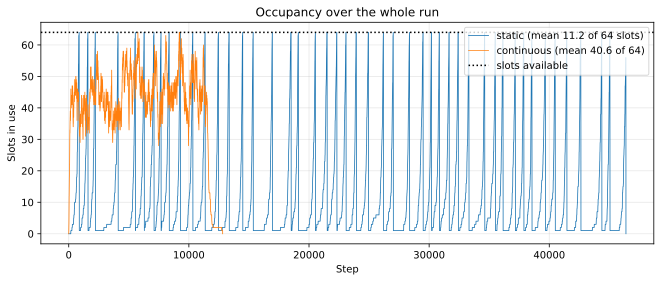

In [5]:
# A request occupies a slot for `length` steps, and the last one is its finish step.
def occupancy(finish_steps, lengths, horizon):
  busy = np.zeros(int(horizon)+2)
  for finish_step, length in zip(finish_steps, lengths):
    busy[int(finish_step-length):int(finish_step)] += 1
  return busy

static_occupancy = occupancy(static_finish, lengths, static_finish.max())
continuous_occupancy = occupancy(continuous_finish, lengths, continuous_finish.max())

plt.figure(figsize=(11,4))
plt.plot(static_occupancy, lw=.8, label=f'static (mean {static_occupancy.mean():.1f} of {NUM_SLOTS} slots)')
plt.plot(continuous_occupancy, lw=.8, label=f'continuous (mean {continuous_occupancy.mean():.1f} of {NUM_SLOTS})')
plt.axhline(NUM_SLOTS, color='k', ls=':', label='slots available')
plt.xlabel('Step')
plt.ylabel('Slots in use')
plt.title('Occupancy over the whole run')
plt.legend()
plt.grid(alpha=.3)
plt.show()

In [6]:
print(f'static     kept {100*static_occupancy.mean()/NUM_SLOTS:5.1f}% of its slots busy')
print(f'continuous kept {100*continuous_occupancy.mean()/NUM_SLOTS:5.1f}%')

static     kept  17.5% of its slots busy
continuous kept  63.5%


### The shape of the static curve is the bug

The static curve makes a sawtooth. Every batch starts full. Short requests
finish, and the batch drains. It then sits almost empty and waits for its
longest member. The next batch repeats this.

The continuous curve stays against the ceiling. A slot that empties takes a
new request on the next step, not at the end of the batch.

One more result matters on the JAX track. The batch **dimension never changes
size**. Each slot holds a sequence or stands free. That is already a page
table with one page per sequence, two stages before you build the real one.

    ./vc guide 5